# GANs Explicadas con Ejemplos Súper Sencillos 🎨

## ¿Qué vamos a aprender?

Imagina que tienes:
- Un **falsificador** (Generador) que intenta crear billetes falsos
- Un **detective** (Discriminador) que intenta detectar los billetes falsos

Cada uno aprende del otro, ¡y al final el falsificador es tan bueno que crea billetes perfectos!

**En este notebook:**
1. 🎲 Empezaremos con números aleatorios
2. 📊 Luego haremos formas simples (círculos)
3. 🔢 Después generaremos dígitos (MNIST)
4. 🎭 Finalmente exploraremos cosas avanzadas

In [ ]:
# Instalación de librerías (ejecuta solo si es necesario)
!pip install torch torchvision matplotlib numpy

In [6]:
# Importaciones
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas correctamente")
print(f"Usando: {'GPU 🚀' if torch.cuda.is_available() else 'CPU 💻'}")

✅ Librerías cargadas correctamente
Usando: CPU 💻


---
## 📚 EJEMPLO 1: El concepto más simple - Generando números

### El Problema:
Tenemos números "reales" entre 5 y 10. Queremos entrenar una red que genere números similares.

**Analogía:** Los números reales son como "billetes verdaderos". Queremos que nuestra red aprenda a crear números que parezcan venir del mismo banco.

In [2]:
# EJEMPLO 1.1: Generador Super Simple (genera un número)

class GeneradorSimple(nn.Module):
    """El Falsificador: genera números falsos"""
    def __init__(self):
        super().__init__()
        # Red muy simple: entrada -> capa oculta -> salida
        self.red = nn.Sequential(
            nn.Linear(1, 16),      # Recibe 1 número aleatorio
            nn.ReLU(),              # Activación
            nn.Linear(16, 16),      # Capa oculta
            nn.ReLU(),              # Activación
            nn.Linear(16, 1)        # Genera 1 número
        )
    
    def forward(self, ruido):
        return self.red(ruido)

class DiscriminadorSimple(nn.Module):
    """El Detective: detecta números falsos"""
    def __init__(self):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(1, 16),       # Recibe 1 número
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),       # Sale: 0=falso, 1=real
            nn.Sigmoid()            # Convierte a probabilidad
        )
    
    def forward(self, numero):
        return self.red(numero)

# Crear las redes
generador = GeneradorSimple()
discriminador = DiscriminadorSimple()

print("🎨 Generador creado")
print("🔍 Discriminador creado")
print("\n¡Listo para empezar!")

🎨 Generador creado
🔍 Discriminador creado

¡Listo para empezar!


In [3]:
# EJEMPLO 1.2: Veamos qué genera al principio (sin entrenar)

# Generar 5 números aleatorios
ruido = torch.randn(5, 1)
numeros_falsos = generador(ruido)

print("🎲 Ruido de entrada:")
print(ruido.squeeze().tolist())
print("\n🎨 Números generados (SIN entrenar):")
print(numeros_falsos.detach().squeeze().tolist())
print("\n❌ ¡No parecen estar entre 5 y 10! Necesita entrenamiento.")

🎲 Ruido de entrada:
[-1.79805326461792, 0.0030834325589239597, -1.629144549369812, -0.5433692336082458, 0.14680540561676025]

🎨 Números generados (SIN entrenar):
[0.2521446645259857, 0.21592991054058075, 0.24755805730819702, 0.22078588604927063, 0.21742084622383118]

❌ ¡No parecen estar entre 5 y 10! Necesita entrenamiento.


In [4]:
# EJEMPLO 1.3: Entrenamiento paso a paso

# Configuración
optimizador_G = torch.optim.Adam(generador.parameters(), lr=0.01)
optimizador_D = torch.optim.Adam(discriminador.parameters(), lr=0.01)
criterio = nn.BCELoss()  # Binary Cross Entropy

# Listas para guardar el progreso
historial_D = []
historial_G = []
numeros_generados_epoca = []

print("🏃 Comenzando entrenamiento...\n")

for epoca in range(1000):
    # ----- PASO 1: Entrenar el DISCRIMINADOR -----
    
    # 1a. Números reales (entre 5 y 10)
    numeros_reales = torch.FloatTensor(32, 1).uniform_(5, 10)
    etiquetas_reales = torch.ones(32, 1)  # 1 = real
    
    # 1b. Números falsos del generador
    ruido = torch.randn(32, 1)
    numeros_falsos = generador(ruido)
    etiquetas_falsas = torch.zeros(32, 1)  # 0 = falso
    
    # 1c. El discriminador evalúa ambos
    prediccion_reales = discriminador(numeros_reales)
    prediccion_falsos = discriminador(numeros_falsos.detach())
    
    # 1d. Calcular pérdida y actualizar
    perdida_D = criterio(prediccion_reales, etiquetas_reales) + \
                criterio(prediccion_falsos, etiquetas_falsas)
    
    optimizador_D.zero_grad()
    perdida_D.backward()
    optimizador_D.step()
    
    # ----- PASO 2: Entrenar el GENERADOR -----
    
    # 2a. Generar números falsos
    ruido = torch.randn(32, 1)
    numeros_falsos = generador(ruido)
    
    # 2b. Intentar engañar al discriminador
    prediccion = discriminador(numeros_falsos)
    perdida_G = criterio(prediccion, etiquetas_reales)  # Quiere que piense que son reales!
    
    optimizador_G.zero_grad()
    perdida_G.backward()
    optimizador_G.step()
    
    # Guardar progreso
    historial_D.append(perdida_D.item())
    historial_G.append(perdida_G.item())
    
    # Guardar algunos números generados
    if epoca % 100 == 0:
        with torch.no_grad():
            muestras = generador(torch.randn(5, 1))
            numeros_generados_epoca.append((epoca, muestras.squeeze().tolist()))
        
        print(f"Época {epoca:4d} | Pérdida D: {perdida_D.item():.3f} | Pérdida G: {perdida_G.item():.3f}")
        print(f"  Números generados: {[f'{x:.2f}' for x in muestras.squeeze().tolist()]}")

print("\n✅ ¡Entrenamiento completado!")

🏃 Comenzando entrenamiento...

Época    0 | Pérdida D: 1.415 | Pérdida G: 0.680
  Números generados: ['0.33', '0.32', '0.33', '0.34', '0.31']
Época  100 | Pérdida D: 1.397 | Pérdida G: 0.496
  Números generados: ['4.06', '4.35', '4.14', '3.97', '4.08']
Época  200 | Pérdida D: 1.387 | Pérdida G: 0.673
  Números generados: ['7.10', '7.75', '7.09', '6.98', '7.75']
Época  300 | Pérdida D: 1.386 | Pérdida G: 0.705
  Números generados: ['6.73', '6.73', '8.84', '7.08', '6.73']
Época  400 | Pérdida D: 1.386 | Pérdida G: 0.686
  Números generados: ['7.18', '7.05', '6.81', '9.21', '6.87']
Época  500 | Pérdida D: 1.388 | Pérdida G: 0.680
  Números generados: ['6.54', '6.62', '6.67', '6.69', '6.65']
Época  600 | Pérdida D: 1.388 | Pérdida G: 0.689
  Números generados: ['6.94', '11.68', '7.11', '6.98', '10.83']
Época  700 | Pérdida D: 1.388 | Pérdida G: 0.695
  Números generados: ['8.05', '11.53', '7.38', '8.41', '6.85']
Época  800 | Pérdida D: 1.387 | Pérdida G: 0.691
  Números generados: ['10.25'

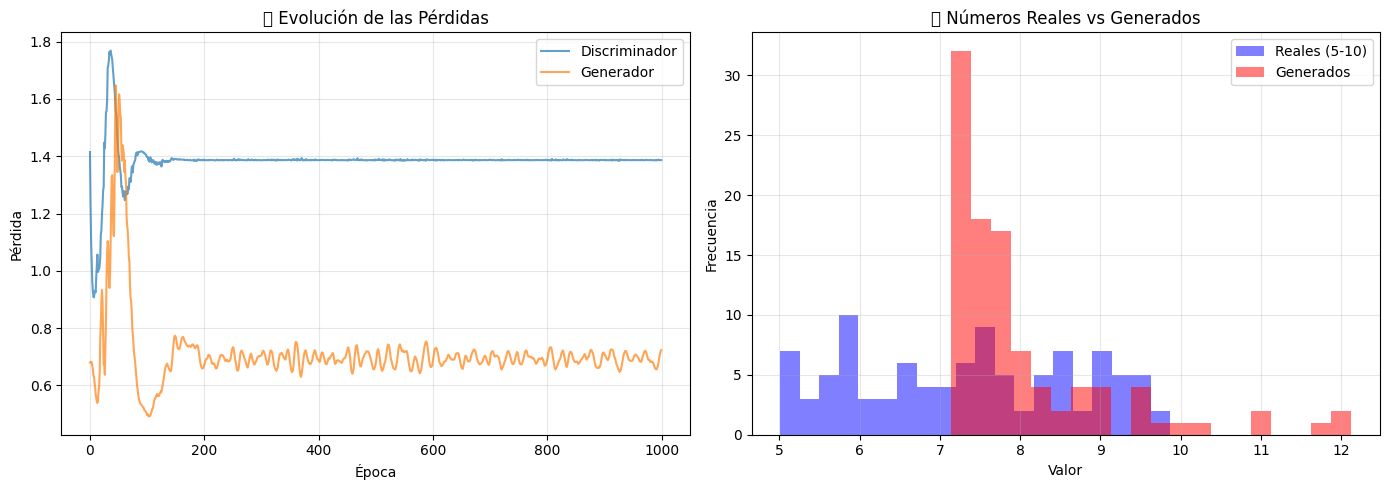


🎯 Estadísticas finales:
Reales - Media: 7.31, Desv: 1.38
Generados - Media: 8.02, Desv: 1.08


In [7]:
# EJEMPLO 1.4: Visualizar resultados

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Pérdidas
axes[0].plot(historial_D, label='Discriminador', alpha=0.7)
axes[0].plot(historial_G, label='Generador', alpha=0.7)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('📉 Evolución de las Pérdidas')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfica 2: Números generados vs reales
with torch.no_grad():
    numeros_finales = generador(torch.randn(100, 1)).squeeze().numpy()
    numeros_reales_muestra = np.random.uniform(5, 10, 100)

axes[1].hist(numeros_reales_muestra, bins=20, alpha=0.5, label='Reales (5-10)', color='blue')
axes[1].hist(numeros_finales, bins=20, alpha=0.5, label='Generados', color='red')
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('📊 Números Reales vs Generados')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🎯 Estadísticas finales:")
print(f"Reales - Media: {numeros_reales_muestra.mean():.2f}, Desv: {numeros_reales_muestra.std():.2f}")
print(f"Generados - Media: {numeros_finales.mean():.2f}, Desv: {numeros_finales.std():.2f}")

### 🤔 ¿Qué acabamos de ver?

1. **Al principio:** El generador creaba números aleatorios sin sentido
2. **Durante el entrenamiento:** 
   - El discriminador aprendió a detectar números fuera del rango 5-10
   - El generador aprendió a crear números en ese rango para engañarlo
3. **Al final:** El generador crea números muy parecidos a los reales

**¡Esto es una GAN en su forma más simple! 🎉**

---
## 🎨 EJEMPLO 2: Generando Formas 2D (Círculos)

### El Problema:
Ahora en vez de números, vamos a generar puntos (x, y) que formen un círculo.

**Analogía:** Los puntos reales forman un círculo perfecto. Queremos que la GAN aprenda a generar puntos que también formen un círculo.

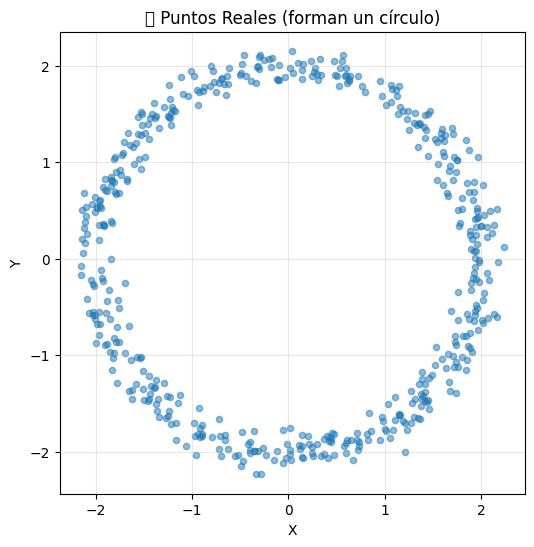

📍 Estos son nuestros datos reales: puntos que forman un círculo


In [8]:
# EJEMPLO 2.1: Crear datos reales (puntos en un círculo)

def generar_puntos_circulo(n_puntos, radio=2):
    """Genera puntos que forman un círculo"""
    angulos = np.random.uniform(0, 2*np.pi, n_puntos)
    x = radio * np.cos(angulos)
    y = radio * np.sin(angulos)
    # Añadir un poco de ruido
    x += np.random.normal(0, 0.1, n_puntos)
    y += np.random.normal(0, 0.1, n_puntos)
    return np.column_stack([x, y])

# Visualizar los puntos reales
puntos_reales = generar_puntos_circulo(500)

plt.figure(figsize=(6, 6))
plt.scatter(puntos_reales[:, 0], puntos_reales[:, 1], alpha=0.5, s=20)
plt.title('⭕ Puntos Reales (forman un círculo)')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

print("📍 Estos son nuestros datos reales: puntos que forman un círculo")

In [9]:
# EJEMPLO 2.2: GAN para generar puntos 2D

class Generador2D(nn.Module):
    def __init__(self, dim_ruido=2):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(dim_ruido, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 2)  # Genera (x, y)
        )
    
    def forward(self, z):
        return self.red(z)

class Discriminador2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(2, 32),      # Recibe (x, y)
            nn.LeakyReLU(0.2),
            nn.Linear(32, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    
    def forward(self, punto):
        return self.red(punto)

# Crear redes
gen_2d = Generador2D()
disc_2d = Discriminador2D()

print("✅ GAN 2D creada")

✅ GAN 2D creada


🏃 Entrenando y visualizando evolución...



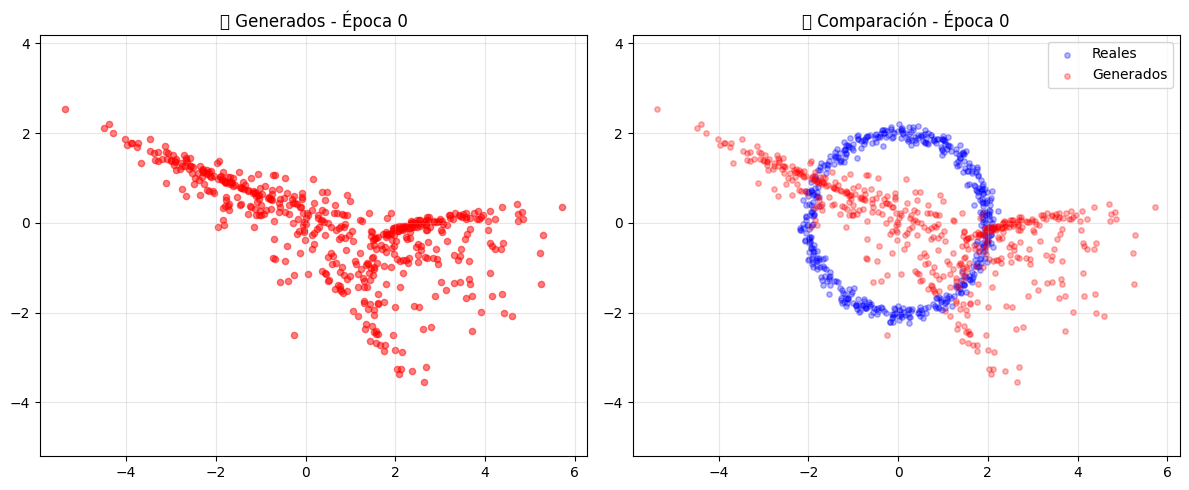

Época    0 | Pérdida D: 1.480 | Pérdida G: 0.731



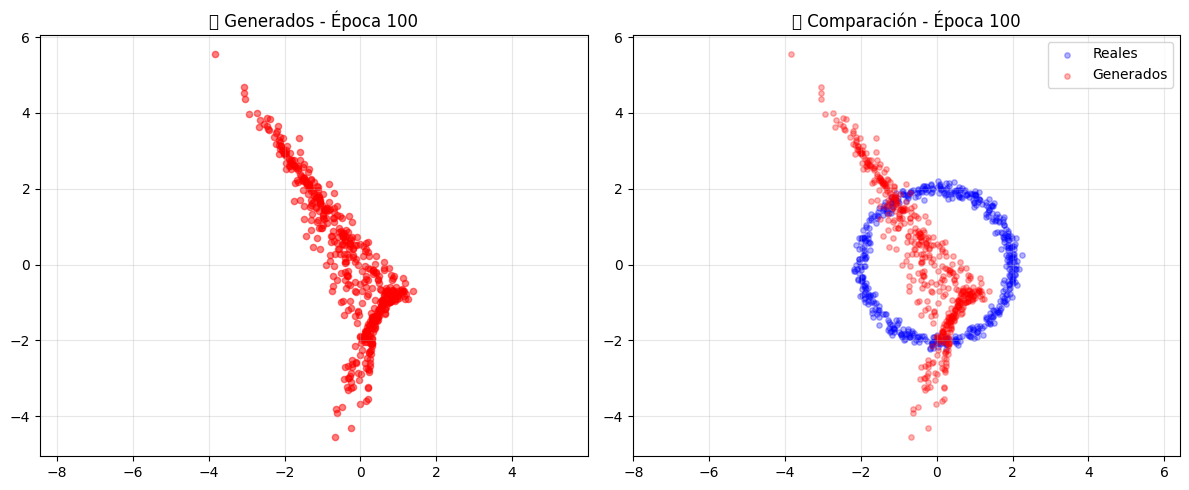

Época  100 | Pérdida D: 1.231 | Pérdida G: 0.776



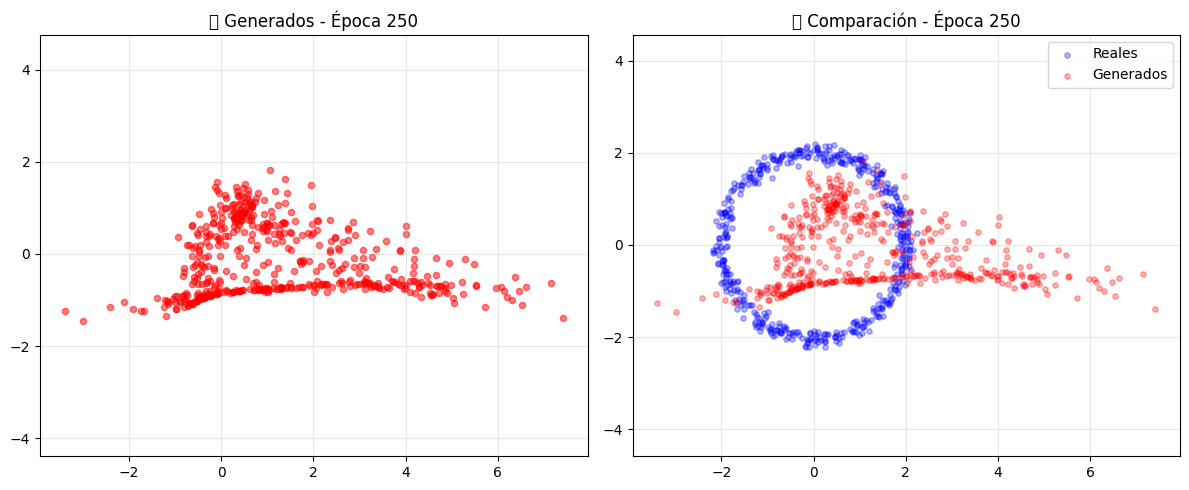

Época  250 | Pérdida D: 1.284 | Pérdida G: 0.787



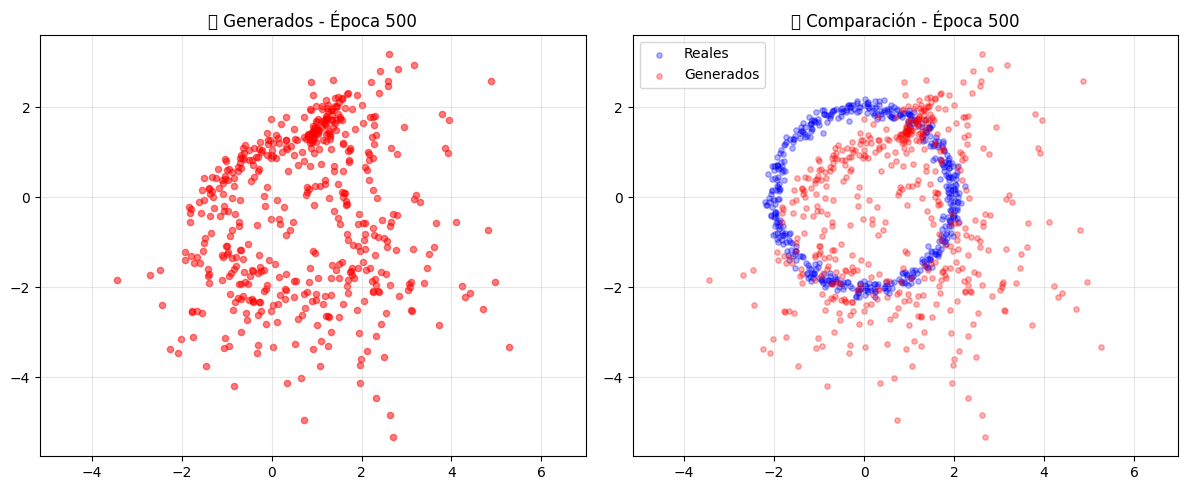

Época  500 | Pérdida D: 1.313 | Pérdida G: 0.831



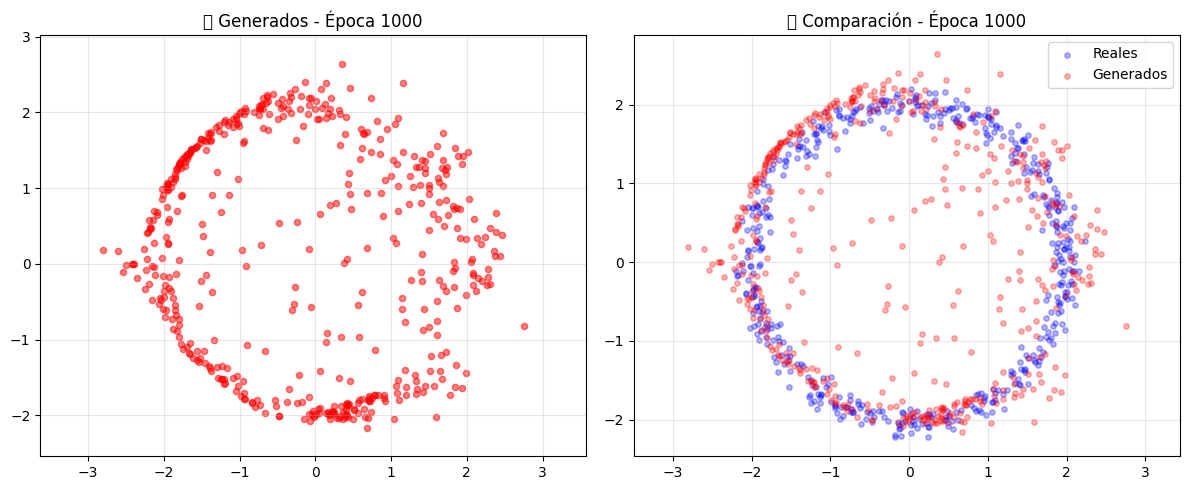

Época 1000 | Pérdida D: 1.335 | Pérdida G: 0.719

✅ ¡Entrenamiento completado! Observa cómo los puntos evolucionan hacia un círculo.


In [11]:
# EJEMPLO 2.3: Visualización por etapas

opt_G = torch.optim.Adam(gen_2d.parameters(), lr=0.001)
opt_D = torch.optim.Adam(disc_2d.parameters(), lr=0.001)
criterio = nn.BCELoss()

# Épocas donde queremos ver el progreso
epocas_visualizar = [0, 100, 250, 500, 1000]
puntos_reales_vis = generar_puntos_circulo(500)

print("🏃 Entrenando y visualizando evolución...\n")

for epoca in range(1001):
    # Entrenar discriminador
    puntos_reales_batch = torch.FloatTensor(generar_puntos_circulo(128))
    etiq_reales = torch.ones(128, 1)
    
    ruido = torch.randn(128, 2)
    puntos_falsos = gen_2d(ruido)
    etiq_falsas = torch.zeros(128, 1)
    
    pred_reales = disc_2d(puntos_reales_batch)
    pred_falsos = disc_2d(puntos_falsos.detach())
    
    perdida_D = criterio(pred_reales, etiq_reales) + criterio(pred_falsos, etiq_falsas)
    
    opt_D.zero_grad()
    perdida_D.backward()
    opt_D.step()
    
    # Entrenar generador
    ruido = torch.randn(128, 2)
    puntos_falsos = gen_2d(ruido)
    pred = disc_2d(puntos_falsos)
    perdida_G = criterio(pred, etiq_reales)
    
    opt_G.zero_grad()
    perdida_G.backward()
    opt_G.step()
    
    # Visualizar en épocas específicas
    if epoca in epocas_visualizar:
        with torch.no_grad():
            puntos_generados = gen_2d(torch.randn(500, 2)).numpy()
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Puntos generados
        axes[0].scatter(puntos_generados[:, 0], puntos_generados[:, 1], 
                       alpha=0.5, s=20, c='red')
        axes[0].set_title(f'🎨 Generados - Época {epoca}', fontsize=12)
        axes[0].set_xlim(-4, 4)
        axes[0].set_ylim(-4, 4)
        axes[0].axis('equal')
        axes[0].grid(True, alpha=0.3)
        
        # Comparación
        axes[1].scatter(puntos_reales_vis[:, 0], puntos_reales_vis[:, 1], 
                       alpha=0.3, s=15, c='blue', label='Reales')
        axes[1].scatter(puntos_generados[:, 0], puntos_generados[:, 1], 
                       alpha=0.3, s=15, c='red', label='Generados')
        axes[1].set_title(f'🔄 Comparación - Época {epoca}', fontsize=12)
        axes[1].set_xlim(-4, 4)
        axes[1].set_ylim(-4, 4)
        axes[1].axis('equal')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print(f"Época {epoca:4d} | Pérdida D: {perdida_D.item():.3f} | Pérdida G: {perdida_G.item():.3f}\n")

print("✅ ¡Entrenamiento completado! Observa cómo los puntos evolucionan hacia un círculo.")

### 🎯 Observaciones importantes:

1. **Al inicio:** Los puntos generados están dispersos aleatoriamente
2. **Durante:** Van formando gradualmente la forma circular
3. **Al final:** Los puntos generados son indistinguibles de los reales

**¡Esto demuestra que las GANs pueden aprender distribuciones complejas!**

---
## 🔢 EJEMPLO 3: Generando Dígitos MNIST (¡Imágenes reales!)

### El Problema:
Ahora sí vamos con imágenes reales. MNIST tiene 28×28 píxeles = 784 números por imagen.

**Analogía:** Cada imagen es como un billete completo con 784 características que debemos copiar perfectamente.

100.0%
100.0%
100.0%
100.0%


📦 Dataset cargado: 60000 imágenes


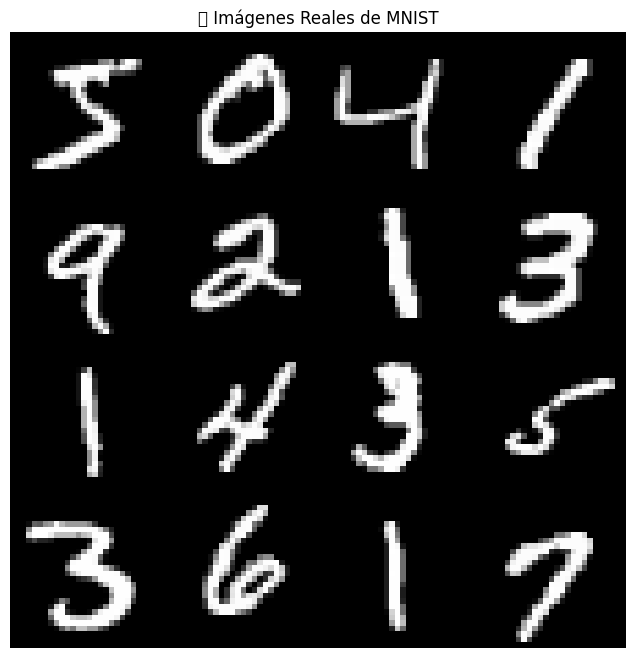

In [12]:
# EJEMPLO 3.1: Cargar y visualizar datos MNIST

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Transformación: convertir a tensor y normalizar a [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Descargar MNIST
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(mnist, batch_size=32, shuffle=True)

print(f"📦 Dataset cargado: {len(mnist)} imágenes")

# Visualizar algunas imágenes reales
ejemplos = [mnist[i][0] for i in range(16)]
grid = torch.cat([torch.cat([ejemplos[i*4+j] for j in range(4)], dim=2) for i in range(4)], dim=1)

plt.figure(figsize=(8, 8))
plt.imshow(grid.squeeze(), cmap='gray')
plt.title('🖼️ Imágenes Reales de MNIST')
plt.axis('off')
plt.show()

In [13]:
# EJEMPLO 3.2: GAN simple para MNIST

class GeneradorMNIST(nn.Module):
    def __init__(self, dim_ruido=100):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(dim_ruido, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),  # 28x28 = 784 píxeles
            nn.Tanh()              # Salida entre -1 y 1
        )
    
    def forward(self, z):
        img = self.red(z)
        return img.view(-1, 1, 28, 28)  # Reshape a imagen

class DiscriminadorMNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),        # Previene overfitting
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    
    def forward(self, img):
        img_plana = img.view(-1, 784)  # Aplanar imagen
        return self.red(img_plana)

# Crear redes
gen_mnist = GeneradorMNIST()
disc_mnist = DiscriminadorMNIST()

# Mover a GPU si está disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gen_mnist = gen_mnist.to(device)
disc_mnist = disc_mnist.to(device)

print(f"✅ GAN para MNIST creada en: {device}")
print(f"📊 Parámetros Generador: {sum(p.numel() for p in gen_mnist.parameters()):,}")
print(f"📊 Parámetros Discriminador: {sum(p.numel() for p in disc_mnist.parameters()):,}")

✅ GAN para MNIST creada en: cpu
📊 Parámetros Generador: 1,486,352
📊 Parámetros Discriminador: 533,505


In [14]:
# EJEMPLO 3.3: Función para visualizar progreso

def visualizar_progreso(generador, epoca, ruido_fijo):
    """Genera y muestra 16 imágenes"""
    with torch.no_grad():
        imagenes_falsas = generador(ruido_fijo).cpu()
    
    # Crear grid 4x4
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(imagenes_falsas[i].squeeze(), cmap='gray')
        ax.axis('off')
    
    plt.suptitle(f'🎨 Imágenes Generadas - Época {epoca}', fontsize=16)
    plt.tight_layout()
    plt.show()

# Ruido fijo para ver evolución
ruido_fijo = torch.randn(16, 100, device=device)

print("✅ Función de visualización lista")

✅ Función de visualización lista


🏃 Comenzando entrenamiento...

💡 Tip: Esto puede tardar unos minutos. Ve por un café ☕
  [1/5][0/1875] D: 0.711 | G: 0.672
  [1/5][200/1875] D: 0.700 | G: 0.818
  [1/5][400/1875] D: 0.558 | G: 1.263
  [1/5][600/1875] D: 0.456 | G: 1.138
  [1/5][800/1875] D: 0.520 | G: 1.304
  [1/5][1000/1875] D: 0.443 | G: 2.548
  [1/5][1200/1875] D: 0.451 | G: 2.081
  [1/5][1400/1875] D: 0.351 | G: 1.891
  [1/5][1600/1875] D: 0.421 | G: 2.327
  [1/5][1800/1875] D: 0.552 | G: 1.257

✅ Época 1 completada


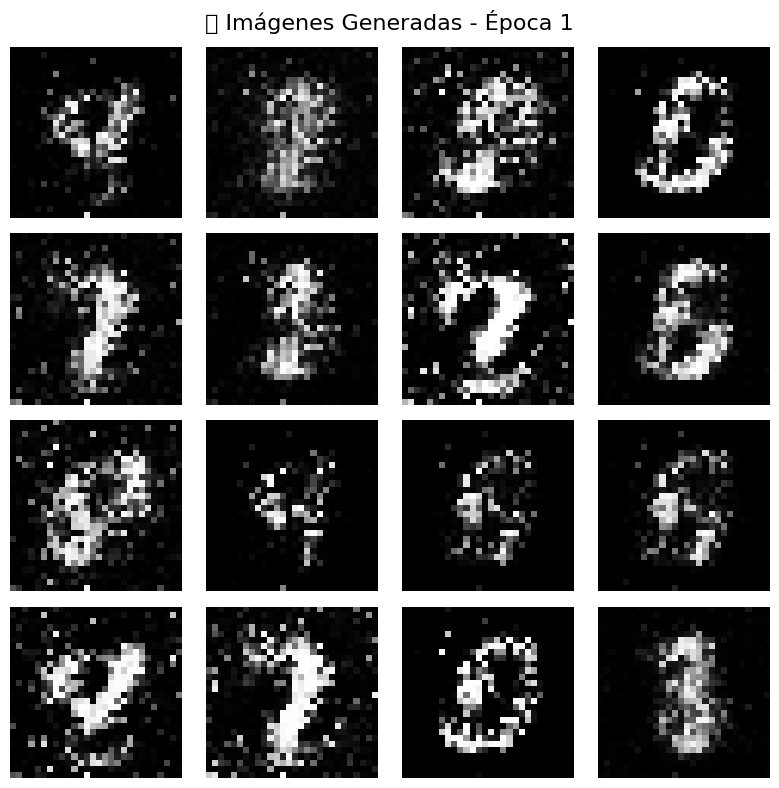

  [2/5][0/1875] D: 0.454 | G: 1.789
  [2/5][200/1875] D: 0.361 | G: 1.790
  [2/5][400/1875] D: 0.593 | G: 2.745
  [2/5][600/1875] D: 0.544 | G: 1.070
  [2/5][800/1875] D: 0.417 | G: 1.747
  [2/5][1000/1875] D: 0.482 | G: 1.486
  [2/5][1200/1875] D: 0.278 | G: 2.349
  [2/5][1400/1875] D: 0.382 | G: 2.656
  [2/5][1600/1875] D: 0.631 | G: 2.892
  [2/5][1800/1875] D: 0.426 | G: 2.007

✅ Época 2 completada


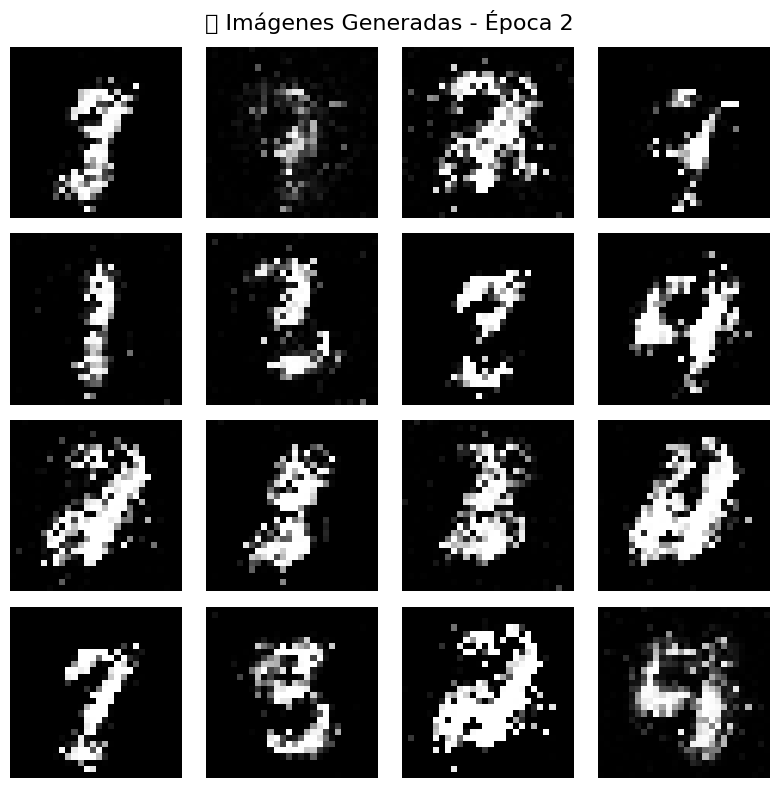

  [3/5][0/1875] D: 0.363 | G: 1.906
  [3/5][200/1875] D: 0.357 | G: 2.254
  [3/5][400/1875] D: 0.316 | G: 2.012
  [3/5][600/1875] D: 0.341 | G: 2.468
  [3/5][800/1875] D: 0.523 | G: 1.710
  [3/5][1000/1875] D: 0.341 | G: 1.505
  [3/5][1200/1875] D: 0.408 | G: 1.999
  [3/5][1400/1875] D: 0.483 | G: 2.120
  [3/5][1600/1875] D: 0.428 | G: 1.967
  [3/5][1800/1875] D: 0.493 | G: 1.355

✅ Época 3 completada


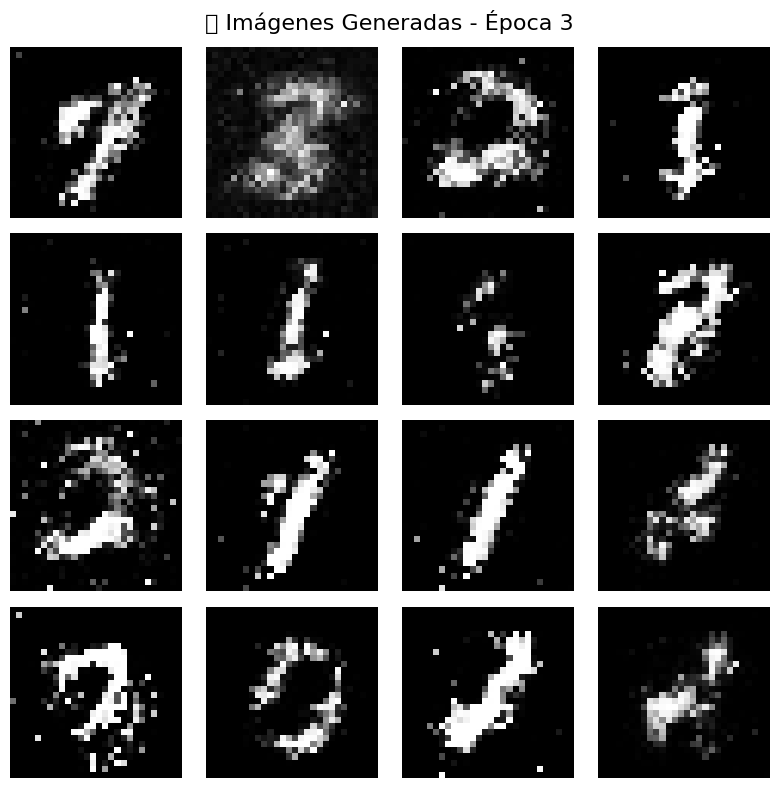

  [4/5][0/1875] D: 0.486 | G: 1.869
  [4/5][200/1875] D: 0.530 | G: 1.587
  [4/5][400/1875] D: 0.573 | G: 1.383
  [4/5][600/1875] D: 0.558 | G: 1.114
  [4/5][800/1875] D: 0.392 | G: 1.107
  [4/5][1000/1875] D: 0.471 | G: 1.528
  [4/5][1200/1875] D: 0.608 | G: 1.306
  [4/5][1400/1875] D: 0.566 | G: 1.096
  [4/5][1600/1875] D: 0.628 | G: 1.531
  [4/5][1800/1875] D: 0.514 | G: 1.003

✅ Época 4 completada


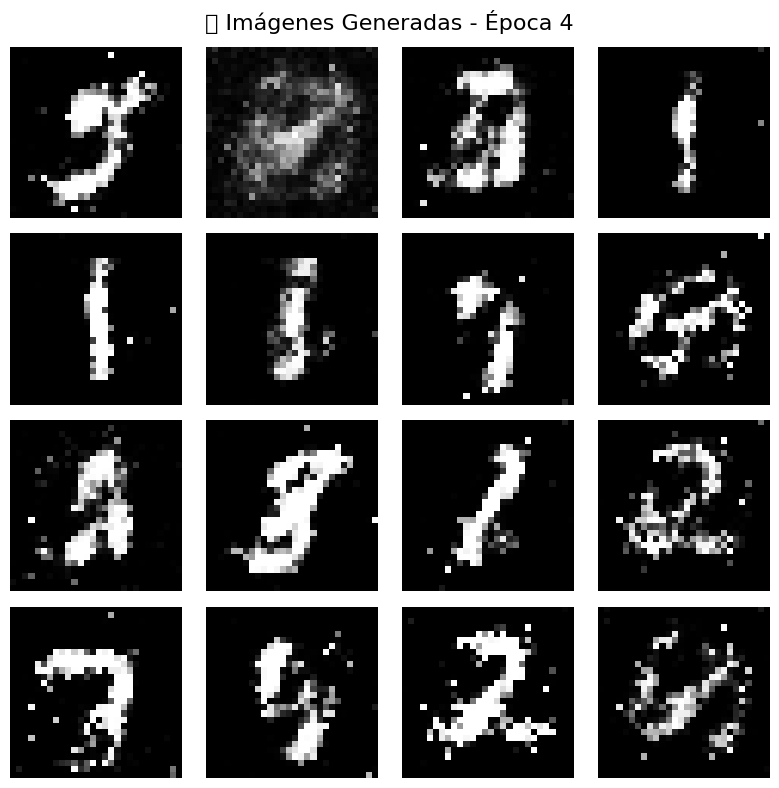

  [5/5][0/1875] D: 0.494 | G: 1.124
  [5/5][200/1875] D: 0.460 | G: 1.357
  [5/5][400/1875] D: 0.530 | G: 1.118
  [5/5][600/1875] D: 0.508 | G: 1.173
  [5/5][800/1875] D: 0.529 | G: 1.236
  [5/5][1000/1875] D: 0.478 | G: 1.290
  [5/5][1200/1875] D: 0.487 | G: 1.104
  [5/5][1400/1875] D: 0.585 | G: 1.096
  [5/5][1600/1875] D: 0.584 | G: 1.487
  [5/5][1800/1875] D: 0.624 | G: 1.176

✅ Época 5 completada


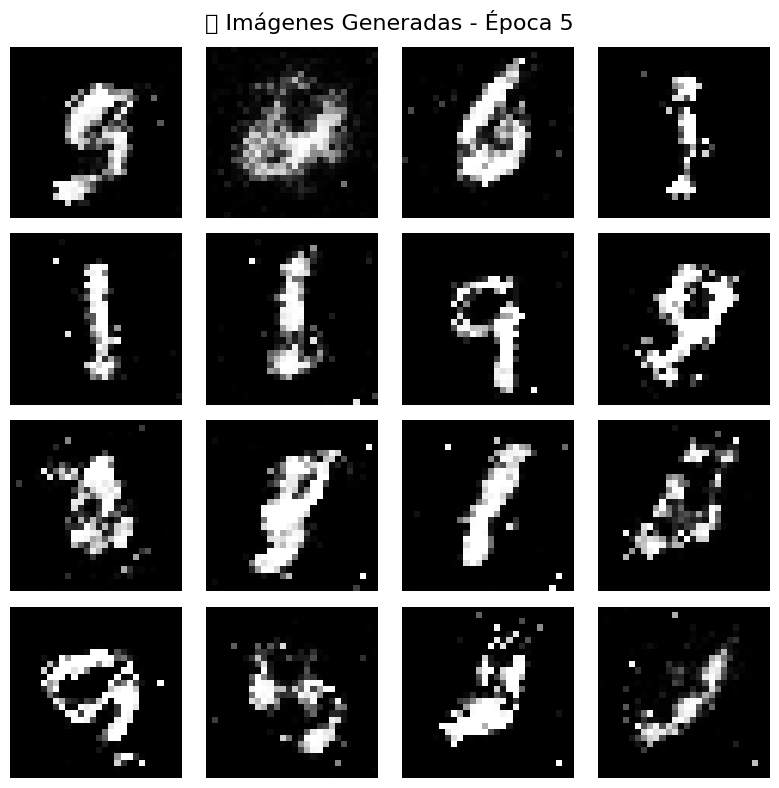


🎉 ¡Entrenamiento completado!


In [15]:
# EJEMPLO 3.4: Entrenamiento MNIST (versión rápida para demo)

opt_G = torch.optim.Adam(gen_mnist.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(disc_mnist.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterio = nn.BCELoss()

num_epocas = 5  # Usa 50+ para mejores resultados
perdidas_D = []
perdidas_G = []

print("🏃 Comenzando entrenamiento...\n")
print("💡 Tip: Esto puede tardar unos minutos. Ve por un café ☕")

for epoca in range(num_epocas):
    perdida_D_epoca = 0
    perdida_G_epoca = 0
    
    for i, (imgs_reales, _) in enumerate(dataloader):
        batch_size = imgs_reales.size(0)
        imgs_reales = imgs_reales.to(device)
        
        # Etiquetas
        etiq_reales = torch.ones(batch_size, 1, device=device)
        etiq_falsas = torch.zeros(batch_size, 1, device=device)
        
        # ----- Entrenar Discriminador -----
        opt_D.zero_grad()
        
        # Imágenes reales
        pred_reales = disc_mnist(imgs_reales)
        perdida_D_real = criterio(pred_reales, etiq_reales)
        
        # Imágenes falsas
        ruido = torch.randn(batch_size, 100, device=device)
        imgs_falsas = gen_mnist(ruido)
        pred_falsas = disc_mnist(imgs_falsas.detach())
        perdida_D_falsa = criterio(pred_falsas, etiq_falsas)
        
        perdida_D = (perdida_D_real + perdida_D_falsa) / 2
        perdida_D.backward()
        opt_D.step()
        
        # ----- Entrenar Generador -----
        opt_G.zero_grad()
        
        ruido = torch.randn(batch_size, 100, device=device)
        imgs_falsas = gen_mnist(ruido)
        pred = disc_mnist(imgs_falsas)
        perdida_G = criterio(pred, etiq_reales)  # Queremos engañar!
        
        perdida_G.backward()
        opt_G.step()
        
        perdida_D_epoca += perdida_D.item()
        perdida_G_epoca += perdida_G.item()
        
        # Mostrar progreso cada 200 batches
        if i % 200 == 0:
            print(f"  [{epoca+1}/{num_epocas}][{i}/{len(dataloader)}] "
                  f"D: {perdida_D.item():.3f} | G: {perdida_G.item():.3f}")
    
    # Guardar pérdidas promedio
    perdidas_D.append(perdida_D_epoca / len(dataloader))
    perdidas_G.append(perdida_G_epoca / len(dataloader))
    
    # Visualizar progreso
    print(f"\n✅ Época {epoca+1} completada")
    visualizar_progreso(gen_mnist, epoca+1, ruido_fijo)

print("\n🎉 ¡Entrenamiento completado!")

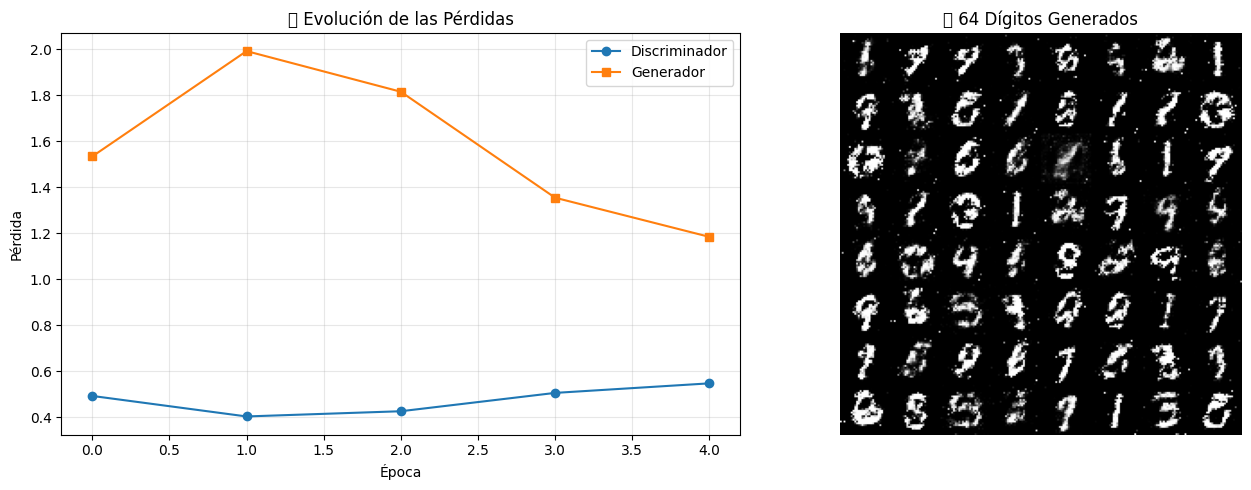


📊 Análisis:
Pérdida final del Discriminador: 0.547
Pérdida final del Generador: 1.185

💡 Idealmente, ambas pérdidas deberían estar cerca de 0.69 (log(2))
   Esto indica que el discriminador acierta ~50% (equilibrio perfecto)


In [16]:
# EJEMPLO 3.5: Análisis de resultados

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de pérdidas
axes[0].plot(perdidas_D, label='Discriminador', marker='o')
axes[0].plot(perdidas_G, label='Generador', marker='s')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('📉 Evolución de las Pérdidas')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Generar muchas imágenes para análisis
with torch.no_grad():
    ruido_analisis = torch.randn(64, 100, device=device)
    imgs_generadas = gen_mnist(ruido_analisis).cpu()

# Mostrar grid más grande
grid = torch.cat([torch.cat([imgs_generadas[i*8+j] for j in range(8)], dim=2) for i in range(8)], dim=1)
axes[1].imshow(grid.squeeze(), cmap='gray')
axes[1].set_title('🎨 64 Dígitos Generados')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\n📊 Análisis:")
print(f"Pérdida final del Discriminador: {perdidas_D[-1]:.3f}")
print(f"Pérdida final del Generador: {perdidas_G[-1]:.3f}")
print("\n💡 Idealmente, ambas pérdidas deberían estar cerca de 0.69 (log(2))")
print("   Esto indica que el discriminador acierta ~50% (equilibrio perfecto)")

---
## 🎭 EJEMPLO 4: Explorando el Espacio Latente

### ¿Qué es el espacio latente?

El **espacio latente** es el "ADN" de las imágenes. Cada punto en este espacio se mapea a una imagen.

**Analogía:** Imagina un panel de control con 100 perillas (cada dimensión del vector z). Mover una perilla cambia una característica de la imagen resultante.

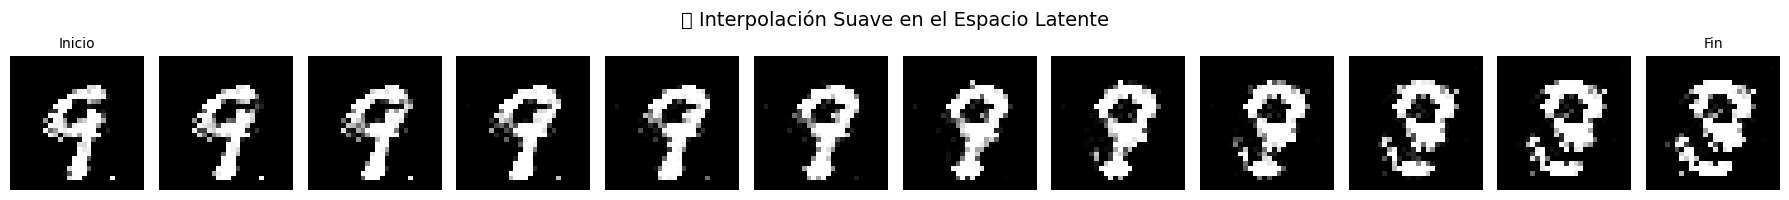


✨ Observa cómo un dígito se transforma suavemente en otro
   ¡Las formas intermedias a veces parecen dígitos diferentes!


In [17]:
# EJEMPLO 4.1: Interpolación entre dos dígitos

def interpolar_imagenes(generador, z1, z2, pasos=10):
    """Crea una transición suave entre dos imágenes"""
    imagenes = []
    
    for alpha in torch.linspace(0, 1, pasos):
        # Mezclar los dos vectores: z = (1-alpha)*z1 + alpha*z2
        z = (1 - alpha) * z1 + alpha * z2
        with torch.no_grad():
            img = generador(z)
        imagenes.append(img.cpu())
    
    return torch.cat(imagenes, dim=0)

# Crear dos puntos aleatorios en el espacio latente
z_inicio = torch.randn(1, 100, device=device)
z_fin = torch.randn(1, 100, device=device)

# Interpolar
transicion = interpolar_imagenes(gen_mnist, z_inicio, z_fin, pasos=12)

# Visualizar
fig, axes = plt.subplots(1, 12, figsize=(18, 2))
for i, ax in enumerate(axes):
    ax.imshow(transicion[i].squeeze(), cmap='gray')
    ax.axis('off')
    if i == 0:
        ax.set_title('Inicio', fontsize=10)
    elif i == 11:
        ax.set_title('Fin', fontsize=10)

plt.suptitle('🔄 Interpolación Suave en el Espacio Latente', fontsize=14)
plt.tight_layout()
plt.show()

print("\n✨ Observa cómo un dígito se transforma suavemente en otro")
print("   ¡Las formas intermedias a veces parecen dígitos diferentes!")

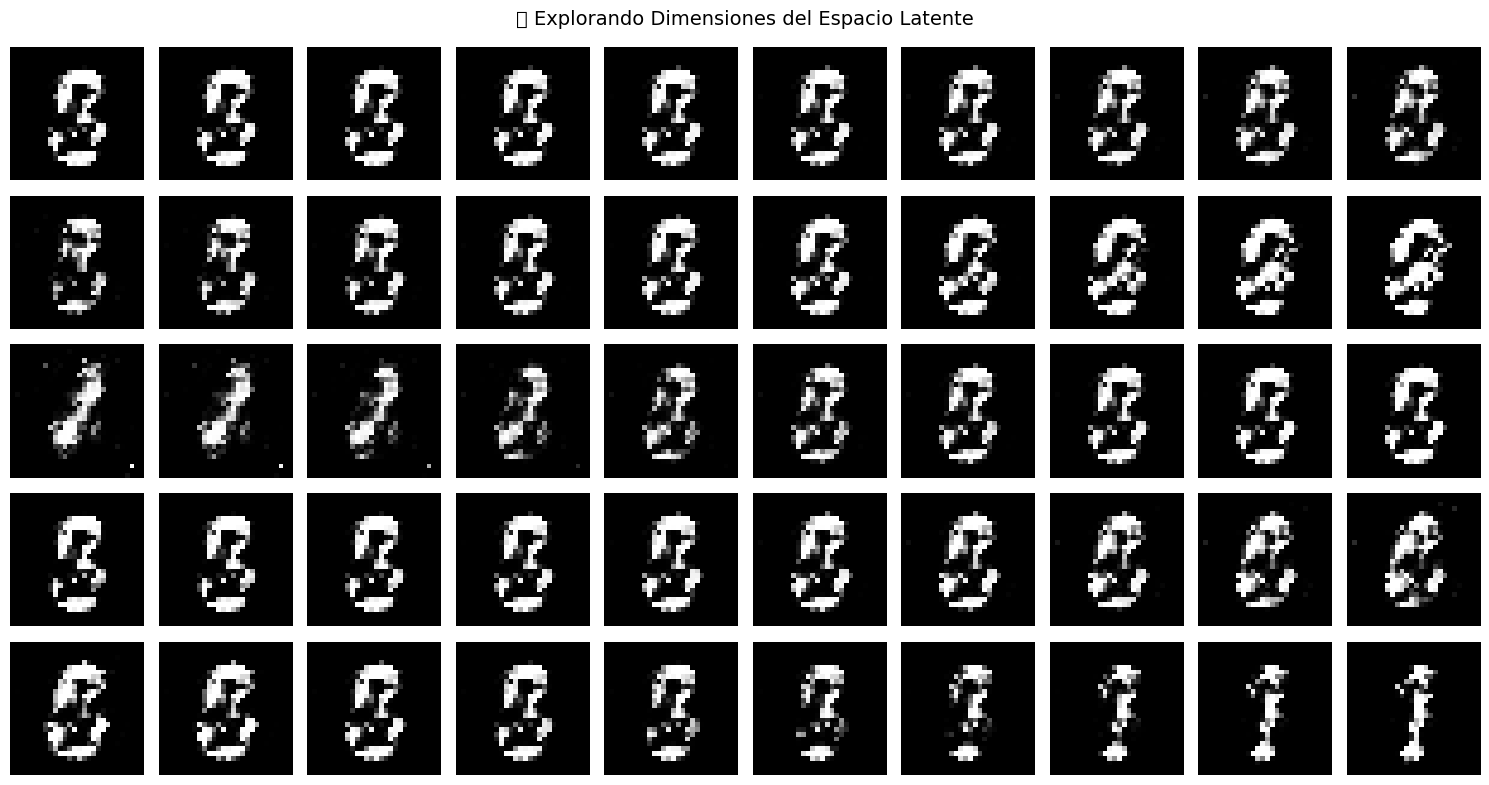


🔍 Cada fila muestra cómo cambia la imagen al variar UNA dimensión
   Algunas dimensiones controlan rotación, grosor, estilo, etc.


In [18]:
# EJEMPLO 4.2: Explorar dimensiones individuales

def explorar_dimension(generador, z_base, dim, valores):
    """Varía una sola dimensión del vector latente"""
    imagenes = []
    
    for valor in valores:
        z = z_base.clone()
        z[0, dim] = valor  # Cambiar solo esta dimensión
        
        with torch.no_grad():
            img = generador(z)
        imagenes.append(img.cpu())
    
    return torch.cat(imagenes, dim=0)

# Vector base
z_base = torch.randn(1, 100, device=device)

# Explorar las primeras 5 dimensiones
valores = torch.linspace(-3, 3, 10)

fig, axes = plt.subplots(5, 10, figsize=(15, 8))

for dim in range(5):
    imagenes = explorar_dimension(gen_mnist, z_base, dim, valores)
    
    for i in range(10):
        axes[dim, i].imshow(imagenes[i].squeeze(), cmap='gray')
        axes[dim, i].axis('off')
    
    axes[dim, 0].set_ylabel(f'Dim {dim}', fontsize=10)

plt.suptitle('🎛️ Explorando Dimensiones del Espacio Latente', fontsize=14)
plt.tight_layout()
plt.show()

print("\n🔍 Cada fila muestra cómo cambia la imagen al variar UNA dimensión")
print("   Algunas dimensiones controlan rotación, grosor, estilo, etc.")

---
## 🎯 EJEMPLO 5: Problemas Comunes y Cómo Detectarlos

### Mode Collapse

**¿Qué es?** El generador se "atasca" produciendo siempre las mismas imágenes.

**Analogía:** El falsificador descubre que un billete de $20 específico siempre engaña al detective, así que solo hace ese y nunca aprende a hacer otros billetes.

🔍 Análisis de Diversidad:
   Varianza promedio: 0.3417
   Similitud entre imágenes: 0.2989
   ✅ Buena diversidad


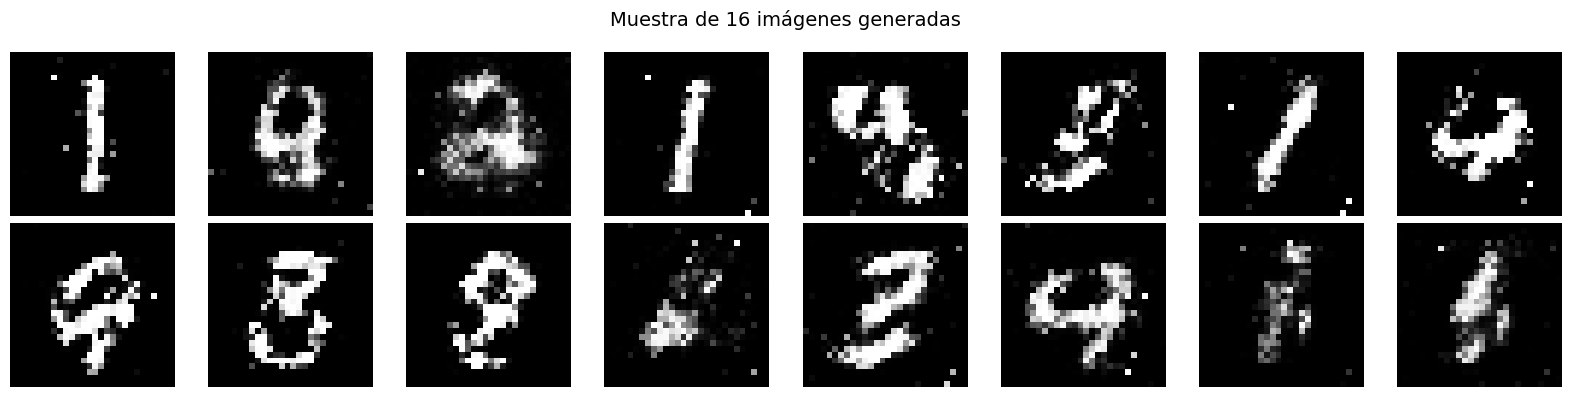

In [19]:
# EJEMPLO 5.1: Detectar Mode Collapse

def detectar_mode_collapse(generador, n_samples=100):
    """Verifica si el generador produce imágenes diversas"""
    with torch.no_grad():
        # Generar muchas imágenes
        ruido = torch.randn(n_samples, 100, device=device)
        imagenes = generador(ruido).cpu().numpy()
    
    # Calcular varianza promedio (diversidad)
    varianza_promedio = np.var(imagenes)
    
    # Calcular similitud entre pares
    imagenes_flat = imagenes.reshape(n_samples, -1)
    similitudes = []
    
    for i in range(min(20, n_samples)):
        for j in range(i+1, min(20, n_samples)):
            # Correlación entre imágenes
            corr = np.corrcoef(imagenes_flat[i], imagenes_flat[j])[0, 1]
            similitudes.append(corr)
    
    similitud_promedio = np.mean(similitudes)
    
    print("🔍 Análisis de Diversidad:")
    print(f"   Varianza promedio: {varianza_promedio:.4f}")
    print(f"   Similitud entre imágenes: {similitud_promedio:.4f}")
    
    if similitud_promedio > 0.8:
        print("   ⚠️ ALERTA: Posible mode collapse detectado!")
        print("   Las imágenes son muy similares entre sí")
    elif varianza_promedio < 0.01:
        print("   ⚠️ ALERTA: Baja diversidad detectada")
    else:
        print("   ✅ Buena diversidad")
    
    # Visualizar muestra
    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(imagenes[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle('Muestra de 16 imágenes generadas', fontsize=14)
    plt.tight_layout()
    plt.show()

# Analizar nuestro generador
detectar_mode_collapse(gen_mnist)

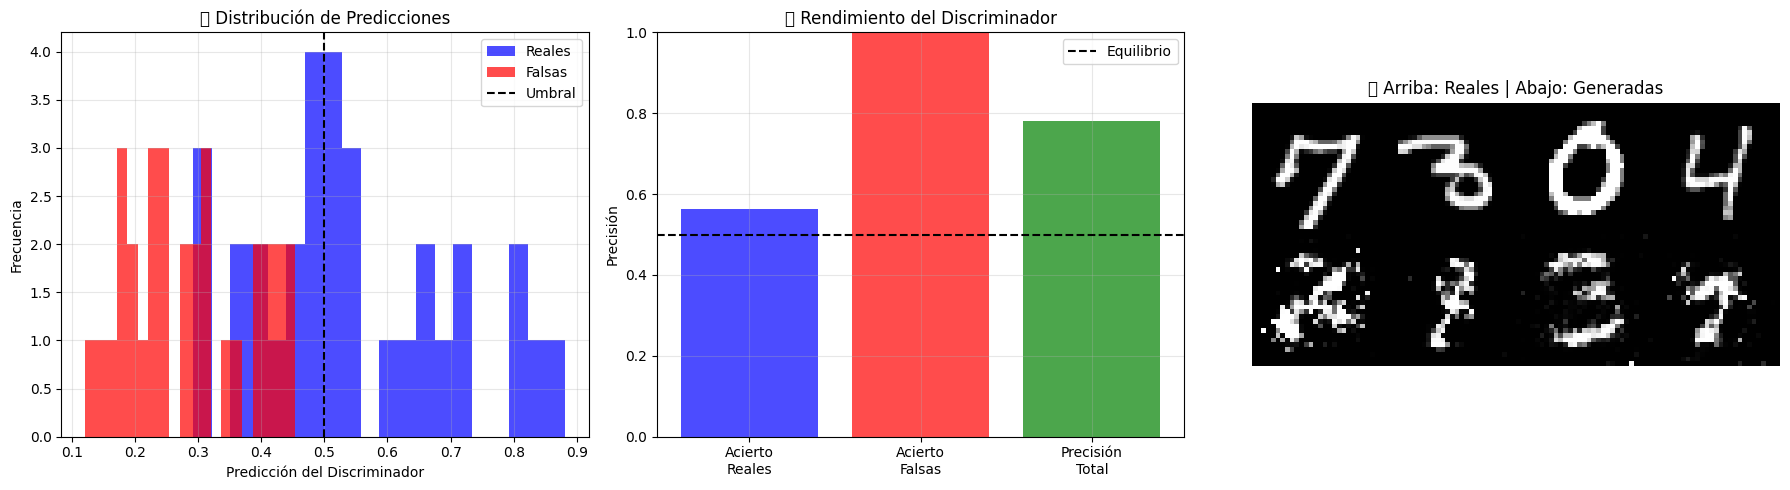


🔬 Diagnóstico:
   Discriminador acierta reales: 56.25%
   Discriminador acierta falsas: 100.00%
   ⚖️ Equilibrio razonable


In [21]:
# EJEMPLO 5.2: Visualizar el equilibrio D vs G (CORREGIDO)

def analizar_equilibrio(discriminador, generador, dataloader):
    """Analiza qué tan bueno es cada componente"""
    discriminador.eval()
    generador.eval()
    
    # Tomar un batch de imágenes reales
    imgs_reales, _ = next(iter(dataloader))
    imgs_reales = imgs_reales[:32].to(device)
    
    # Generar imágenes falsas
    ruido = torch.randn(32, 100, device=device)
    
    with torch.no_grad():  # ✅ MOVER ESTO AQUÍ
        imgs_falsas = generador(ruido)
        
        # Predicciones del discriminador
        pred_reales = discriminador(imgs_reales).cpu().numpy()
        pred_falsas = discriminador(imgs_falsas).cpu().numpy()
    
    # Visualizar
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Histograma de predicciones
    axes[0].hist(pred_reales, bins=20, alpha=0.7, label='Reales', color='blue')
    axes[0].hist(pred_falsas, bins=20, alpha=0.7, label='Falsas', color='red')
    axes[0].axvline(0.5, color='black', linestyle='--', label='Umbral')
    axes[0].set_xlabel('Predicción del Discriminador')
    axes[0].set_ylabel('Frecuencia')
    axes[0].set_title('📊 Distribución de Predicciones')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Métricas
    precision_reales = (pred_reales > 0.5).mean()
    precision_falsas = (pred_falsas < 0.5).mean()
    
    metricas = ['Acierto\nReales', 'Acierto\nFalsas', 'Precisión\nTotal']
    valores = [precision_reales, precision_falsas, (precision_reales + precision_falsas) / 2]
    colores = ['blue', 'red', 'green']
    
    axes[1].bar(metricas, valores, color=colores, alpha=0.7)
    axes[1].axhline(0.5, color='black', linestyle='--', label='Equilibrio')
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel('Precisión')
    axes[1].set_title('🎯 Rendimiento del Discriminador')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Comparación visual (✅ CORREGIDO)
    # Asegurarse de que todo esté en CPU y sin gradientes
    imgs_reales_cpu = imgs_reales[:4].cpu()
    imgs_falsas_cpu = imgs_falsas[:4].cpu()
    
    grid_real = torch.cat([imgs_reales_cpu[i] for i in range(4)], dim=2)
    grid_fake = torch.cat([imgs_falsas_cpu[i] for i in range(4)], dim=2)
    grid_total = torch.cat([grid_real, grid_fake], dim=1)
    
    axes[2].imshow(grid_total.squeeze().numpy(), cmap='gray')  # ✅ .numpy() al final
    axes[2].set_title('🖼️ Arriba: Reales | Abajo: Generadas')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Diagnóstico
    print("\n🔬 Diagnóstico:")
    print(f"   Discriminador acierta reales: {precision_reales:.2%}")
    print(f"   Discriminador acierta falsas: {precision_falsas:.2%}")
    
    if precision_reales > 0.95 and precision_falsas > 0.95:
        print("   ⚠️ El discriminador es DEMASIADO bueno")
        print("   El generador no puede aprender (vanishing gradients)")
    elif precision_reales < 0.6 and precision_falsas < 0.6:
        print("   ⚠️ El discriminador es muy débil")
        print("   El generador no recibe buena retroalimentación")
    elif abs(precision_reales - 0.5) < 0.1 and abs(precision_falsas - 0.5) < 0.1:
        print("   ✅ ¡Equilibrio perfecto! (Nash equilibrium)")
        print("   El discriminador no puede distinguir bien")
    else:
        print("   ⚖️ Equilibrio razonable")

# Analizar
analizar_equilibrio(disc_mnist, gen_mnist, dataloader)

---
## 🎪 EJEMPLO 6: Experimentos Divertidos

### Aritmética en el Espacio Latente

**Concepto loco:** Puedes hacer "operaciones matemáticas" con conceptos visuales!

Por ejemplo, en un generador de caras:
- "Hombre con gafas" - "Hombre" + "Mujer" = "Mujer con gafas"

Aquí lo haremos con dígitos MNIST.

🎯 Buscando versión generada similar a un '7'...


TypeError: Invalid shape (1, 28, 28) for image data

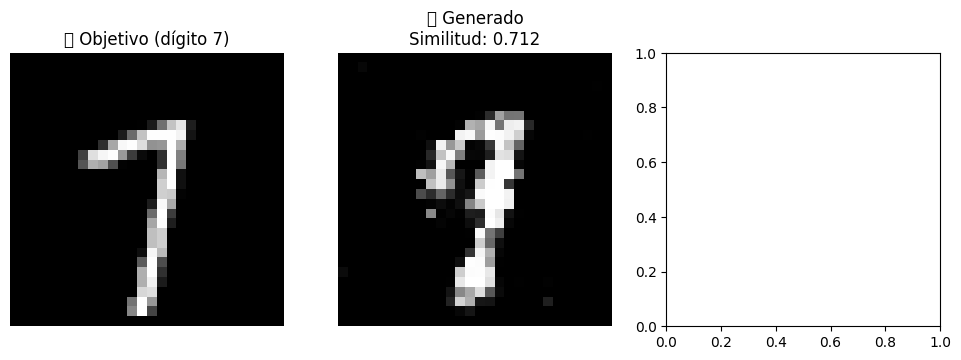

In [22]:
# EJEMPLO 6.1: "Buscar" dígitos específicos en el espacio latente

def encontrar_digito_aproximado(generador, digito_objetivo, n_intentos=1000):
    """Busca vectores latentes que generen un dígito similar al objetivo"""
    mejor_z = None
    mejor_similitud = -float('inf')
    
    with torch.no_grad():
        for _ in range(n_intentos):
            z = torch.randn(1, 100, device=device)
            img_generada = generador(z)
            
            # Calcular similitud (correlación simple)
            similitud = torch.corrcoef(torch.stack([
                img_generada.flatten(),
                digito_objetivo.flatten()
            ]))[0, 1]
            
            if similitud > mejor_similitud:
                mejor_similitud = similitud
                mejor_z = z.clone()
    
    return mejor_z, mejor_similitud

# Tomar un dígito real como objetivo
img_objetivo, label = mnist[42]  # Número 42, ¡la respuesta a todo!
img_objetivo_device = img_objetivo.to(device)

print(f"🎯 Buscando versión generada similar a un '{label}'...")
z_encontrado, similitud = encontrar_digito_aproximado(gen_mnist, img_objetivo_device, n_intentos=500)

# Generar imagen
with torch.no_grad():
    img_generada = gen_mnist(z_encontrado)

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_objetivo.squeeze(), cmap='gray')
axes[0].set_title(f'🎯 Objetivo (dígito {label})')
axes[0].axis('off')

axes[1].imshow(img_generada.cpu().squeeze(), cmap='gray')
axes[1].set_title(f'🎨 Generado\nSimilitud: {similitud:.3f}')
axes[1].axis('off')

# Diferencia
diferencia = torch.abs(img_objetivo_device - img_generada.squeeze())
axes[2].imshow(diferencia.cpu(), cmap='hot')
axes[2].set_title('🔥 Diferencia')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"\n✅ Encontrado! Similitud: {similitud:.3f}")

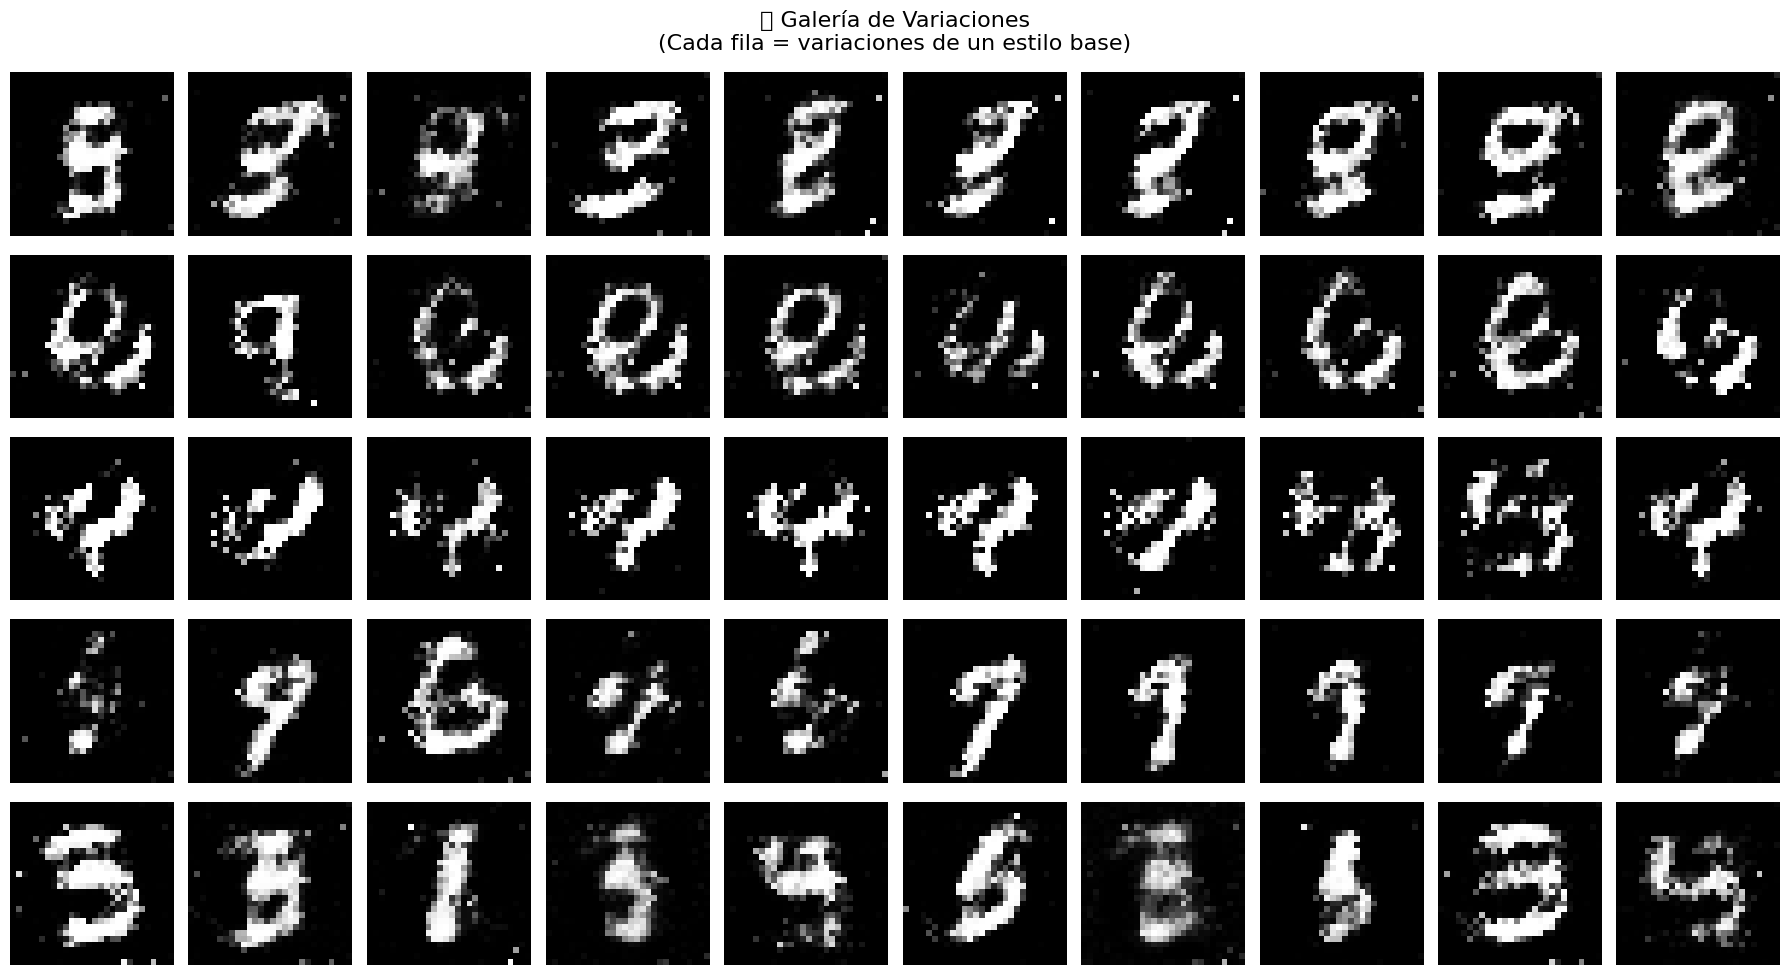

In [23]:
# EJEMPLO 6.2: Crear una "galería" de estilos

def generar_galeria(generador, n_filas=5, n_cols=10):
    """Genera una galería organizada de dígitos"""
    with torch.no_grad():
        # Generar vectores base para cada fila
        bases = [torch.randn(1, 100, device=device) for _ in range(n_filas)]
        
        imagenes = []
        for base in bases:
            fila_imgs = []
            for j in range(n_cols):
                # Añadir pequeñas variaciones
                z = base + torch.randn(1, 100, device=device) * 0.5
                img = generador(z)
                fila_imgs.append(img)
            imagenes.append(fila_imgs)
    
    # Visualizar
    fig, axes = plt.subplots(n_filas, n_cols, figsize=(18, 10))
    
    for i in range(n_filas):
        for j in range(n_cols):
            axes[i, j].imshow(imagenes[i][j].cpu().squeeze(), cmap='gray')
            axes[i, j].axis('off')
    
    plt.suptitle('🎨 Galería de Variaciones\n(Cada fila = variaciones de un estilo base)', 
                 fontsize=16)
    plt.tight_layout()
    plt.show()

generar_galeria(gen_mnist)

---
## 📝 RESUMEN: Conceptos Clave Aprendidos

### 1. ¿Qué es una GAN?
- **Dos redes** que compiten: Generador (falsificador) vs Discriminador (detective)
- **Entrenamiento alternado**: Cada una mejora mientras la otra permanece fija
- **Objetivo**: Llegar a un equilibrio donde el generador es perfecto

### 2. Componentes Principales

**Generador:**
- Entrada: Vector de ruido aleatorio (z)
- Salida: Imagen (o dato que queremos generar)
- Objetivo: Engañar al discriminador

**Discriminador:**
- Entrada: Imagen (real o falsa)
- Salida: Probabilidad de ser real (0 a 1)
- Objetivo: Detectar imágenes falsas

### 3. Proceso de Entrenamiento

```
Repetir por muchas épocas:
    1. Entrenar Discriminador:
       - Mostrarle imágenes reales (etiquetar como 1)
       - Mostrarle imágenes falsas (etiquetar como 0)
       - Actualizar pesos para mejorar clasificación
    
    2. Entrenar Generador:
       - Generar imágenes falsas
       - Intentar que el discriminador las clasifique como reales
       - Actualizar pesos para mejorar generación
```

### 4. Problemas Comunes

**Mode Collapse:**
- El generador produce siempre imágenes muy similares
- Solución: Usar técnicas de regularización, minibatch discrimination

**Vanishing Gradients:**
- El discriminador es tan bueno que el generador no aprende
- Solución: Usar non-saturating loss, ajustar learning rates

**Inestabilidad:**
- Las pérdidas oscilan sin converger
- Solución: Usar arquitecturas estables (DCGAN), normalización

### 5. Trucos Importantes

1. **Normalizar datos** a [-1, 1] y usar Tanh en el generador
2. **LeakyReLU** en el discriminador en vez de ReLU
3. **Adam optimizer** con lr=0.0002 y betas=(0.5, 0.999)
4. **Label smoothing**: Usar 0.9 en vez de 1.0 para etiquetas reales
5. **Entrenar D más veces** que G (típicamente ratio 1:1 o 2:1)

### 6. Aplicaciones Reales

- **Generación de imágenes**: Rostros, paisajes, arte
- **Aumento de datos**: Crear más ejemplos de entrenamiento
- **Super-resolución**: Mejorar calidad de imágenes
- **Transferencia de estilo**: Convertir fotos en pinturas
- **Síntesis de voz**: Crear voces realistas
- **Generación de música**: Componer melodías

